In [1]:
from time import time
import pandas as pd
import numpy as np
from collections import OrderedDict
import warnings

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.colors

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier,
    RandomForestClassifier, ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

from sklearn.preprocessing import StandardScaler

In [2]:
from plotting_code import apply_style
apply_style()

In [3]:
def instantiate_model(model_name):
    model = model_name()
    return model

def fit_model(model, X_train, y_train):
    ti = time()
    model = instantiate_model(model)
    model.fit(X_train, y_train)
    fit_time = time() - ti
    return model, fit_time

def append_result_df(df, result_dict):
    df_result_appended = pd.concat([df, pd.DataFrame([result_dict])], ignore_index=True)
    return df_result_appended

def append_model_dict(dic, model_name, model):
    dic[model_name] = model
    return dic

def evaluate_model(model, X, y_act):
    y_pred = model.predict(X)
    acc = accuracy_score(y_act, y_pred)
    f1 = f1_score(y_act, y_pred, average="weighted", zero_division=0)
    precision = precision_score(y_act, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_act, y_pred, average="weighted", zero_division=0)
    return acc, f1, precision, recall

def fit_evaluate_model(model, model_name, X_train, y_train, X_val, y_val):
    model, fit_time = fit_model(model, X_train, y_train)
    acc_train, f1_train, prec_train, rec_train = evaluate_model(model, X_train, y_train)
    acc_val, f1_val, prec_val, rec_val = evaluate_model(model, X_val, y_val)
    result_dict = {
        'model_name': model_name,
        'model_name_pretty': type(model).__name__,
        'model_params': model.get_params(),
        'fit_time': fit_time,
        'acc_train': acc_train,
        'f1_train': f1_train,
        'precision_train': prec_train,
        'recall_train': rec_train,
        'acc_val': acc_val,
        'f1_val': f1_val,
        'precision_val': prec_val,
        'recall_val': rec_val,
    }
    return model, result_dict

# Read in featurised dataset

In [4]:
df_train = pd.read_csv('approx_dataset_splits/app_train_split.csv')
df_test = pd.read_csv('approx_dataset_splits/app_test_split.csv')
df_val = pd.read_csv('approx_dataset_splits/app_val_split.csv')

In [5]:
df_train.head()

,HMS,Chemical,Temperature,Pressure,Crystal_System,formula,all_valence_s_sum,all_valence_s_avg,all_valence_s_dev,all_valence_s_mode,...,var_gordy_en_max,var_gordy_en_range,var_gordy_en_mode,var_mb_en_sum,var_mb_en_avg,var_mb_en_dev,var_mb_en_min,var_mb_en_max,var_mb_en_range,var_mb_en_mode
0,P 4/m m m,Nd1Ba1Mn1Fe1O5.45,293.0,0.101325,tetragonal,Nd1Ba1Mn1Fe1O5.45,10.90,1.153439,0.988158,2.0,...,0.465308,0.259122,0.465308,0.114709,0.038236,0.027528,0.0,0.063694,0.063694,0.0
1,P 4/m m m,Nd1Ba1Mn1Fe1O5.17,293.0,0.101325,tetragonal,Nd1Ba1Mn1Fe1O5.17,10.34,1.127590,0.991827,2.0,...,0.465308,0.259122,0.465308,0.115040,0.038347,0.027580,0.0,0.063694,0.063694,0.0
2,P 42 m c,Ca1Mn1Ti1.8V0.2O6,293.0,0.101325,tetragonal,Ca1Mn1Ti1.8V0.2O6,12.00,1.200000,0.979796,2.0,...,0.252836,0.046650,0.232343,0.054324,0.018108,0.023888,0.0,0.051546,0.051546,0.0
3,P 42 m c,Ca1Mn1Ti1.4V0.6O6,293.0,0.101325,tetragonal,Ca1Mn1Ti1.4V0.6O6,12.00,1.200000,0.979796,2.0,...,0.252836,0.046650,0.232343,0.059880,0.019960,0.022932,0.0,0.051546,0.051546,0.0
4,P 42 m c,Ca1Mn1Ti1.2V0.8O6,293.0,0.101325,tetragonal,Ca1Mn1Ti1.2V0.8O6,12.00,1.200000,0.979796,2.0,...,0.252836,0.046650,0.232343,0.062658,0.020886,0.022381,0.0,0.051546,0.051546,0.0


In [6]:
df_train["Crystal_System"] = df_train["Crystal_System"].astype("category")
df_test["Crystal_System"] = df_test["Crystal_System"].astype("category")
df_val["Crystal_System"] = df_val["Crystal_System"].astype("category")

label_mapping = dict(enumerate(df_train["Crystal_System"].cat.categories))
print(label_mapping)

{0: 'cubic', 1: 'hexagonal', 2: 'monoclinic', 3: 'orthorhombic', 4: 'tetragonal', 5: 'triclinic', 6: 'trigonal'}


In [7]:
categories = df_train["Crystal_System"].cat.categories
print(categories)

df_train["Crystal_System"] = df_train["Crystal_System"].cat.set_categories(categories)
df_val["Crystal_System"]   = df_val["Crystal_System"].cat.set_categories(categories)
df_test["Crystal_System"]  = df_test["Crystal_System"].cat.set_categories(categories)

df_train["target"] = df_train["Crystal_System"].cat.codes
df_val["target"]   = df_val["Crystal_System"].cat.codes
df_test["target"]  = df_test["Crystal_System"].cat.codes

Index(['cubic', 'hexagonal', 'monoclinic', 'orthorhombic', 'tetragonal',
       'triclinic', 'trigonal'],
      dtype='object')


In [8]:
# Define which columns are your features (drop non-numeric / target cols)
feature_cols = [col for col in df_train.columns if col not in ['HMS', 'Chemical', 'Crystal_System', 'target', 'formula']]

# Training
X_train = df_train[feature_cols].values
y_train = df_train['target'].values

# Validation
X_val = df_val[feature_cols].values
y_val = df_val['target'].values

# Test
X_test = df_test[feature_cols].values
y_test = df_test['target'].values

In [9]:
print(feature_cols)
print(X_train.shape)  # should be (n_samples, n_features)
print(y_train.shape)  # should be (n_samples,)
print(label_mapping)

['Temperature', 'Pressure', 'all_valence_s_sum', 'all_valence_s_avg', 'all_valence_s_dev', 'all_valence_s_mode', 'all_unfilled_valence_s_sum', 'all_unfilled_valence_s_avg', 'all_unfilled_valence_s_dev', 'all_unfilled_valence_s_mode', 'all_valence_p_sum', 'all_valence_p_avg', 'all_valence_p_dev', 'all_valence_p_mode', 'all_unfilled_valence_p_sum', 'all_unfilled_valence_p_avg', 'all_unfilled_valence_p_dev', 'all_unfilled_valence_p_mode', 'all_valence_d_sum', 'all_valence_d_avg', 'all_valence_d_dev', 'all_valence_d_max', 'all_valence_d_range', 'all_valence_d_mode', 'all_unfilled_valence_d_sum', 'all_unfilled_valence_d_avg', 'all_unfilled_valence_d_dev', 'all_unfilled_valence_d_min', 'all_unfilled_valence_d_range', 'all_unfilled_valence_d_mode', 'all_unfilled_valence_f_sum', 'all_unfilled_valence_f_avg', 'all_unfilled_valence_f_dev', 'all_valence_total_sum', 'all_valence_total_avg', 'all_valence_total_dev', 'all_valence_total_min', 'all_valence_total_max', 'all_valence_total_range', 'all_v

In [10]:
print(f"NaNs in X_train: {np.isnan(X_train).sum()}")
print(f"NaNs in X_val: {np.isnan(X_val).sum()}")

# To see which feature columns have NaNs
nan_cols = df_train[feature_cols].isnull().sum()
print(nan_cols[nan_cols > 0])

NaNs in X_train: 0
NaNs in X_val: 0
Series([], dtype: int64)


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit only on train
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Running Classification models

In [12]:
df_classics = pd.DataFrame(columns=[
    'model_name',
    'model_name_pretty',
    'model_params',
    'fit_time',
    'acc_train',
    'f1_train',
    'precision_train',
    'recall_train',
    'acc_val',
    'f1_val',
    'precision_val',
    'recall_val'
])

RANDOM_SEED = 42

classic_model_classes = OrderedDict({
    'dumc': DummyClassifier,
    'lr':   LogisticRegression,
    'abc':  AdaBoostClassifier,
    'gbc':  GradientBoostingClassifier,
    'rfc':  RandomForestClassifier,
    'etc':  ExtraTreesClassifier,
    'svc':  SVC,
    'lsvc': LinearSVC,
    'knc':  KNeighborsClassifier,
})

# Models with seeds and convergence fixes applied
classic_model_names = OrderedDict({
    'dumc': lambda: DummyClassifier(random_state=RANDOM_SEED),
    'lr':   lambda: LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    'abc':  lambda: AdaBoostClassifier(random_state=RANDOM_SEED),
    'gbc':  lambda: GradientBoostingClassifier(random_state=RANDOM_SEED),
    'rfc':  lambda: RandomForestClassifier(random_state=RANDOM_SEED),
    'etc':  lambda: ExtraTreesClassifier(random_state=RANDOM_SEED),
    'svc':  lambda: SVC(random_state=RANDOM_SEED),
    'lsvc': lambda: LinearSVC(random_state=RANDOM_SEED, max_iter=5000),
    'knc':  lambda: KNeighborsClassifier(),  # no random_state needed
})

df_classics = pd.DataFrame()
classic_models = OrderedDict()

np.random.seed(RANDOM_SEED)

ti = time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for model_name, model in classic_model_names.items():
        print(f'Now fitting and evaluating model {model_name}: {model}')
        model, result_dict = fit_evaluate_model(
            model, model_name, X_train, y_train, X_val, y_val
        )
        df_classics = append_result_df(df_classics, result_dict)
        classic_models = append_model_dict(classic_models, model_name, model)

dt = time() - ti
print(f'Finished fitting {len(classic_models)} models, total time: {dt:0.2f} s')

Now fitting and evaluating model dumc: <function <lambda> at 0x0000026069EC2AC0>
Now fitting and evaluating model lr: <function <lambda> at 0x0000026069EC1800>
Now fitting and evaluating model abc: <function <lambda> at 0x0000026069EC2CA0>
Now fitting and evaluating model gbc: <function <lambda> at 0x0000026069EC0A40>
Now fitting and evaluating model rfc: <function <lambda> at 0x0000026069EC09A0>
Now fitting and evaluating model etc: <function <lambda> at 0x0000026069EC2A20>
Now fitting and evaluating model svc: <function <lambda> at 0x0000026069EC14E0>
Now fitting and evaluating model lsvc: <function <lambda> at 0x0000026069EC2D40>
Now fitting and evaluating model knc: <function <lambda> at 0x0000026069EC2DE0>
Finished fitting 9 models, total time: 110.62 s


In [13]:
# Sort in order of increasing validation r2 score
df_classics = df_classics.sort_values('f1_val', ignore_index=True)
df_classics

,model_name,model_name_pretty,model_params,fit_time,acc_train,f1_train,precision_train,recall_train,acc_val,f1_val,precision_val,recall_val
0,dumc,DummyClassifier,"{'constant': None, 'random_state': 42, 'strate...",0.000000,0.313544,0.149686,0.098310,0.313544,0.273973,0.117838,0.075061,0.273973
1,abc,AdaBoostClassifier,"{'algorithm': 'deprecated', 'estimator': None,...",1.674619,0.609153,0.603838,0.609435,0.609153,0.573059,0.566155,0.580595,0.573059
2,svc,SVC,"{'C': 1.0, 'break_ties': False, 'cache_size': ...",0.238788,0.761286,0.758634,0.769532,0.761286,0.655251,0.647743,0.662240,0.655251
3,knc,KNeighborsClassifier,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.002602,0.787879,0.786155,0.786183,0.787879,0.668950,0.665711,0.672764,0.668950
4,lr,LogisticRegression,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.987153,0.861472,0.860846,0.863126,0.861472,0.698630,0.695780,0.703030,0.698630
5,lsvc,LinearSVC,"{'C': 1.0, 'class_weight': None, 'dual': 'auto...",36.480325,0.889301,0.888784,0.890823,0.889301,0.712329,0.709763,0.718819,0.712329
6,rfc,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",1.066876,0.988250,0.988252,0.988317,0.988250,0.808219,0.807297,0.809688,0.808219
7,gbc,GradientBoostingClassifier,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",64.524423,0.977118,0.977126,0.977365,0.977118,0.819635,0.818421,0.819965,0.819635
8,etc,ExtraTreesClassifier,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",0.495423,0.988250,0.988238,0.988421,0.988250,0.831050,0.830317,0.831078,0.831050


# Assessing best classification model

In [26]:
# Find the best-performing model that we have tested
best_row = df_classics.iloc[-1, :].copy()

# Get the model type and model parameters
model_name = best_row['model_name']
model_params = best_row['model_params']

# Instantiate the model again using the parameters
model = classic_model_classes[model_name](**model_params)
print(model)
print(model.get_params())

ExtraTreesClassifier(random_state=42)
{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [27]:
# Concatenate the train and validation datasets together
X_train_final = np.concatenate((X_train, X_val), axis=0)
y_train_final = np.concatenate((y_train, y_val), axis=0)

print(X_train_final.shape)

ti = time()

model.fit(X_train_final, y_train_final)

dt = time() - ti
print(f'Finished fitting best model, total time: {dt:0.2f} s')

y_act_test = y_test
y_pred_test = model.predict(X_test)

acc, f1, precision, recall = evaluate_model(model, X_test, y_test)
print('Accuracy',acc)
print('F1', f1)
print('Precision', precision)
print('Recall', recall)   

(2055, 394)
Finished fitting best model, total time: 1.00 s
Accuracy 0.8596491228070176
F1 0.8621681206768532
Precision 0.8713612239154033
Recall 0.8596491228070176


In [28]:
# Get class labels from label mapping
class_labels = [label_mapping[i] for i in sorted(label_mapping.keys())]
print(classification_report(y_test, y_pred_test, target_names=class_labels))

              precision    recall  f1-score   support

       cubic       0.85      0.91      0.88        32
   hexagonal       0.81      0.81      0.81        16
  monoclinic       0.68      0.82      0.74        28
orthorhombic       0.86      0.88      0.87        48
  tetragonal       1.00      0.76      0.86        29
   triclinic       0.57      0.67      0.62         6
    trigonal       0.95      0.91      0.93        69

    accuracy                           0.86       228
   macro avg       0.82      0.82      0.82       228
weighted avg       0.87      0.86      0.86       228



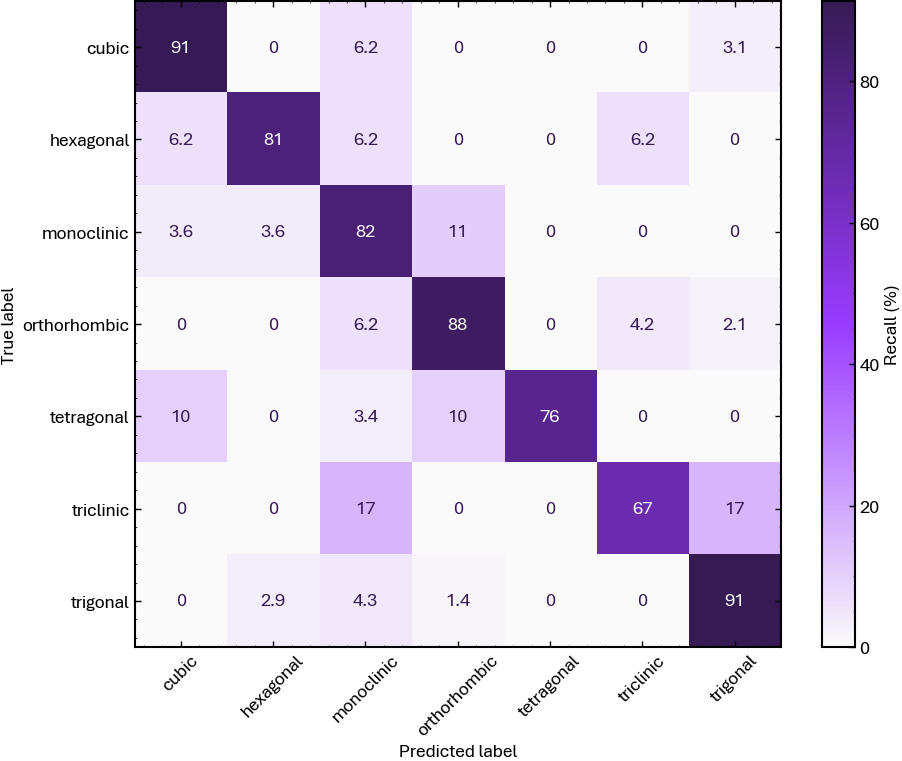

In [29]:
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#fafafa", "#993bff", "#361a54"])

# Normalised version (shows % of each true class correctly predicted)
cm_norm = confusion_matrix(y_test, y_pred_test, normalize='true')
cm_percent = (cm_norm * 100).round(1)  # convert to percentages rounded to 1dp

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_labels)
disp.plot(ax=ax, cmap=custom_cmap, colorbar=True, xticks_rotation=45)
disp.im_.colorbar.set_label('Recall (%)')
    
plt.tight_layout()
plt.savefig('outputs/confusion_matrix_etc_normalised.png', dpi=300, bbox_inches='tight')
plt.show()

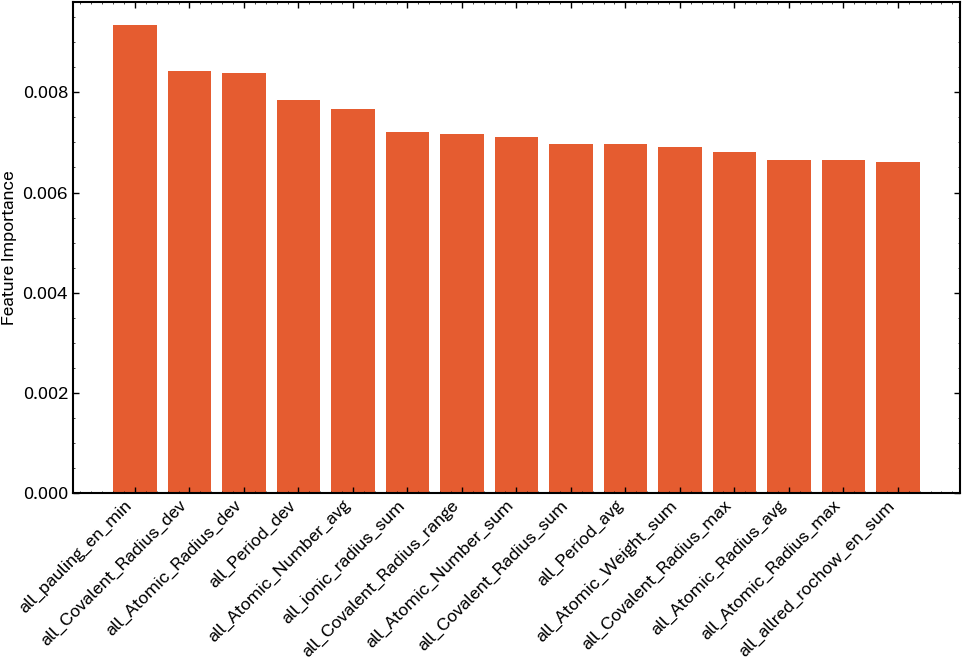

In [30]:
def plot_feature_importances(model, feature_names, top_n=None):
    if not hasattr(model, "feature_importances_"):
        raise ValueError(f"Model type {type(model)} does not have feature_importances_.")
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    if top_n is not None:
        indices = indices[:top_n]
    
    plt.figure(figsize=(10, 7))
    plt.bar(range(len(indices)), importances[indices], color = '#e55c30')
    plt.xticks(range(len(indices)), np.array(feature_names)[indices], rotation=45, ha="right")
    plt.ylabel("Feature Importance")
    plt.tight_layout()
    plt.show()

plot_feature_importances(model, feature_cols, top_n = 15)

# SHAP Values for analysis

In [38]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Get class names - handle both list and dict
if isinstance(label_mapping, dict):
    class_names = [label_mapping[i] for i in range(7)]
else:
    class_names = label_mapping

# Calculate mean absolute SHAP values for each class
mean_shap_values = []
for i in range(7):  # 7 classes
    class_shap = shap_values[:, :, i]
    mean_shap = np.abs(class_shap).mean(axis=0)
    mean_shap_values.append(mean_shap)

# Create DataFrame with class names as index
shap_df = pd.DataFrame(mean_shap_values, columns=feature_cols, index=class_names).T

# Calculate total importance across all classes to find top 8 features
shap_df['total'] = shap_df.sum(axis=1)
top_5_features = shap_df.nlargest(5, 'total').drop('total', axis=1)

In [39]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

cmap_trunc = truncate_colormap(cm.inferno, minval=0.1, maxval=0.9)

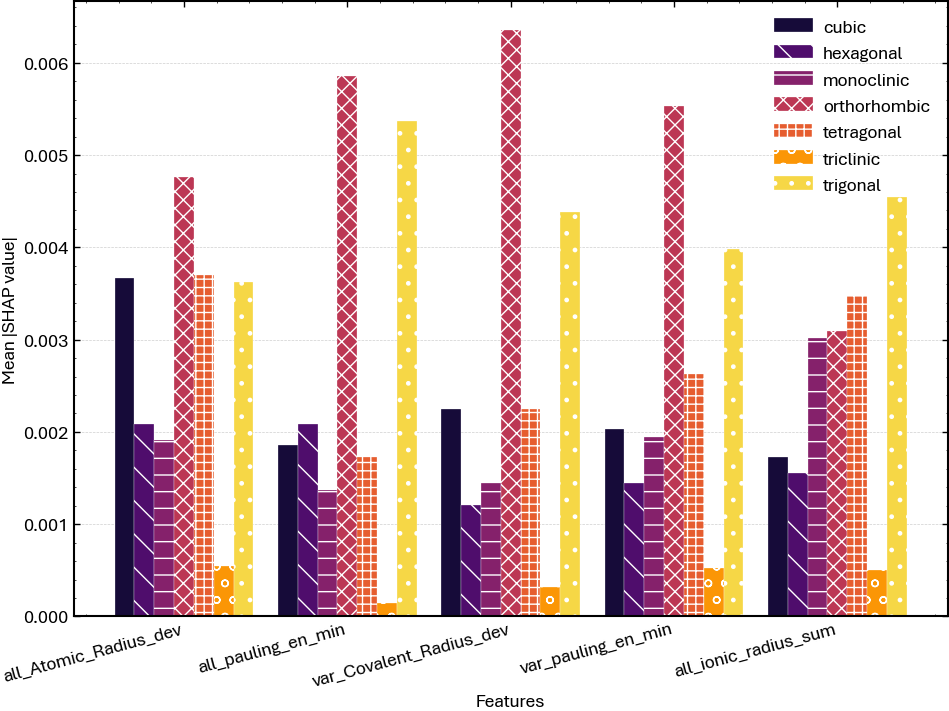

In [96]:
fig, ax = plt.subplots(figsize=(10, 7.5))

ax = top_5_features.plot(
    kind='bar',
    ax=ax,
    width=0.85,
    colormap=cmap_trunc,
    edgecolor='black',
    linewidth=0.3
)

hatches = ['', '\\',  '-', 'xx', '++', 'o',  '.',]

# Rotate x labels properly
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

# Labels
ax.set_ylabel('Mean |SHAP value|')
ax.set_xlabel('Features')

# Improve grid (subtle, not overwhelming)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)

# Optional: reduce visual noise from hatching
use_hatching = True

if use_hatching:
    bars = ax.containers
    for i, container in enumerate(bars):
        for bar in container:
            bar.set_hatch(hatches[i])
            bar.set_edgecolor('white')
            bar.set_linewidth(0.2)

ax.legend(
    ncol=1,
    loc='upper right',
)

plt.tight_layout()
plt.savefig('outputs/SHAP_mean.png', dpi=300, bbox_inches='tight')
plt.show()

In [90]:
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

# explainer = shap.Explainer(model)
shap_values = explainer(X_test_df)

Class:cubic


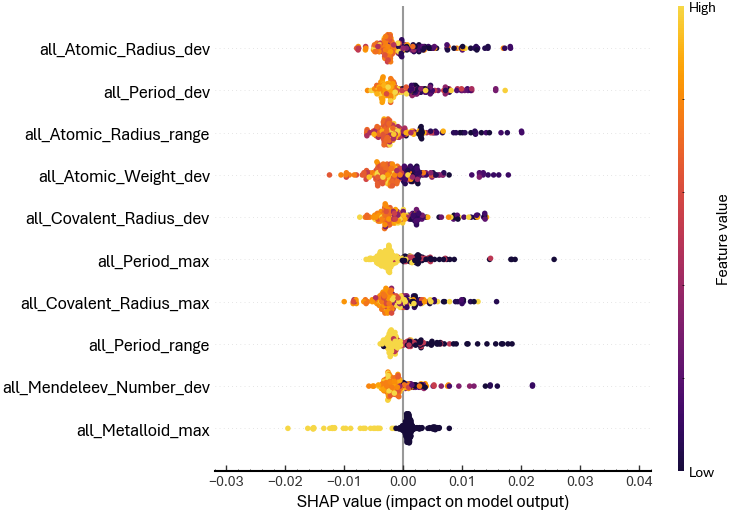

Class:hexagonal


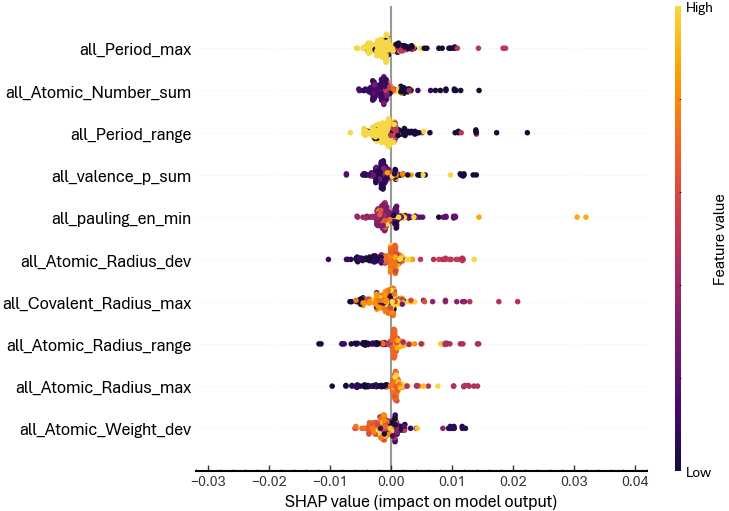

Class:monoclinic


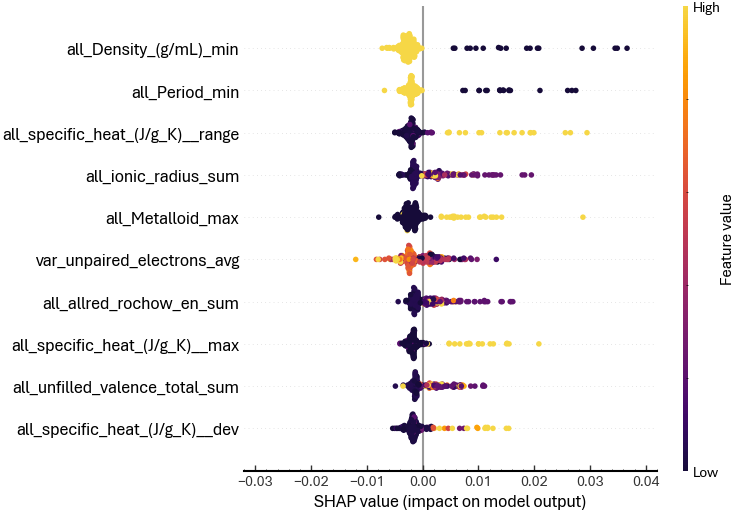

Class:orthorhombic


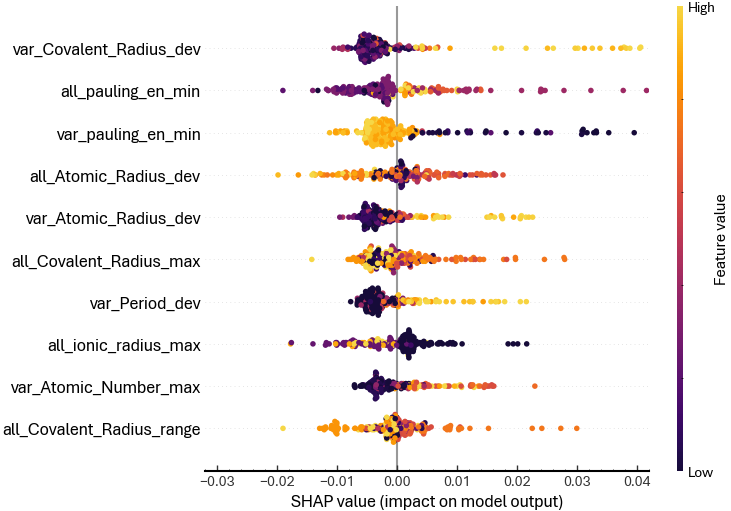

Class:tetragonal


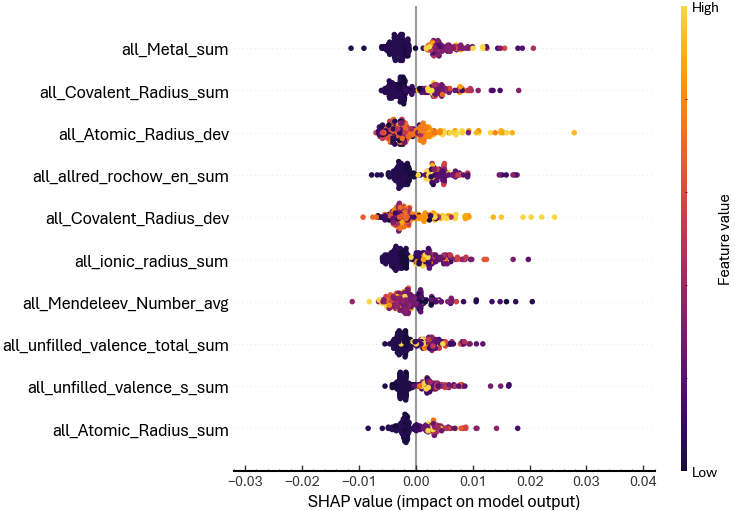

Class:triclinic


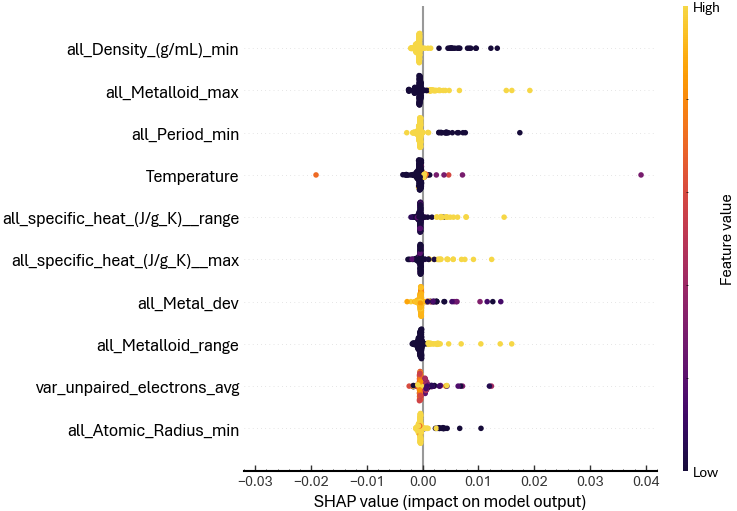

Class:trigonal


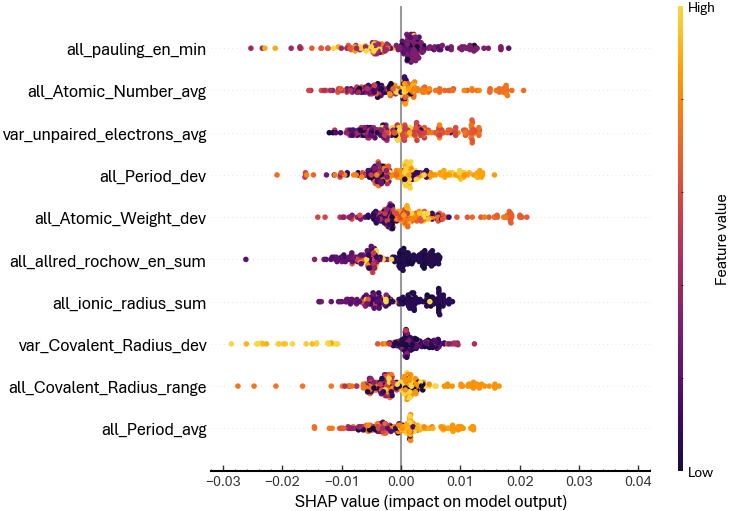

In [95]:
for i in range(7):
    shap_values_cat = shap_values[..., i]
    
    mean_abs = np.abs(shap_values_cat.values).mean(axis=0)
    top10_idx = np.argsort(mean_abs)[-10:]
    
    shap_top10 = shap.Explanation(
        values=shap_values_cat.values[:, top10_idx],
        base_values=shap_values_cat.base_values,
        data=shap_values_cat.data[:, top10_idx] if shap_values_cat.data is not None else None,
        feature_names=[feature_cols[j] for j in top10_idx] 
    )
    
    shap.plots.beeswarm(shap_top10, max_display=10, color=cmap_trunc, show=False)
    ax = plt.gca()
    ax.set_xlabel("SHAP value (impact on model output)")
    # ax.set_title(f"Class: {label_mapping[i]}")
    print(f"Class:{label_mapping[i]}")
    ax.set_xlim(-0.032,0.042)
    for label in ax.get_yticklabels():
        label.set_color('black')
    plt.tight_layout()
    plt.show()

In [24]:
from tqdm import tqdm
seeds = [42, 123, 456, 789, 1024, 2024, 314, 99, 7, 2000]
models_to_evaluate = ['etc', 'rfc', 'lr', 'lsvc']
seed_rows = []

for seed in tqdm(seeds, desc='Seeds'):
    for model_name in tqdm(models_to_evaluate, desc='Models', leave=False):
        
        model_params = df_classics.loc[df_classics['model_name'] == model_name].iloc[0]['model_params'].copy()
        model_params['random_state'] = seed
        
        model = classic_model_classes[model_name](**model_params)
        model.fit(X_train_final, y_train_final)
        
        acc, f1, precision, recall = evaluate_model(model, X_test, y_test)
        
        seed_rows.append({
            'seed':      seed,
            'model':     model_name,
            'test_acc':  acc,
            'test_f1':   f1,
            'test_prec': precision,
            'test_rec':  recall,
        })

seed_df = pd.DataFrame(seed_rows)

summary = seed_df.groupby('model').agg(
    acc_mean=('test_acc', 'mean'),
    acc_std= ('test_acc', 'std'),
    f1_mean= ('test_f1',  'mean'),
    f1_std=  ('test_f1',  'std'),
).round(4)

print(summary)

seed_df['feature_set'] = 'approx' 
seed_df.to_csv('results/approx_seed_results.csv', index=False)

Seeds: 100%|██████████| 10/10 [10:40<00:00, 64.05s/it]

       acc_mean  acc_std  f1_mean  f1_std
model                                    
etc      0.8535   0.0042   0.8556  0.0045
lr       0.7149   0.0000   0.7112  0.0000
lsvc     0.7368   0.0000   0.7348  0.0000
rfc      0.8526   0.0072   0.8549  0.0070
